In [1]:
import pandas as pd

df = pd.read_csv("Downloads/Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [2]:
restaurant_count = df['Restaurant Name'].value_counts()

chains = restaurant_count[restaurant_count > 1]

print("Top Restaurant Chains:")
print(chains.head(10))

Top Restaurant Chains:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


In [3]:
top_chains = chains.head(10)

top_chains

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

In [4]:
chain_ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean()

top_chain_ratings = chain_ratings.loc[top_chains.index]

print("Average Ratings of Top Chains:")
print(round(top_chain_ratings, 2))

Average Ratings of Top Chains:
Restaurant Name
Cafe Coffee Day     2.42
Domino's Pizza      2.74
Subway              2.91
Green Chick Chop    2.67
McDonald's          3.34
Keventers           2.87
Pizza Hut           3.32
Giani               2.69
Baskin Robbins      1.86
Barbeque Nation     4.35
Name: Aggregate rating, dtype: float64


In [5]:
chain_votes = df.groupby('Restaurant Name')['Votes'].mean()

top_chain_votes = chain_votes.loc[top_chains.index]

print("Average Votes of Top Chains:")
print(round(top_chain_votes, 2))

Average Votes of Top Chains:
Restaurant Name
Cafe Coffee Day       29.25
Domino's Pizza        84.09
Subway                97.21
Green Chick Chop      18.90
McDonald's           110.23
Keventers             37.15
Pizza Hut            165.37
Giani                 29.45
Baskin Robbins        15.29
Barbeque Nation     1082.38
Name: Votes, dtype: float64


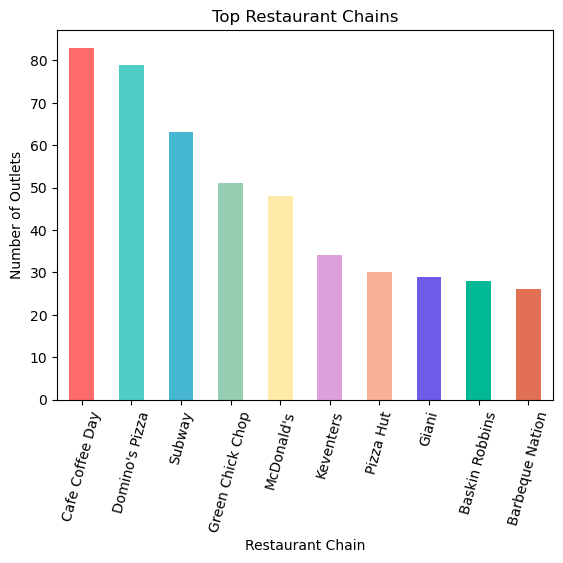

In [6]:
import matplotlib.pyplot as plt

top_chains.plot(
    kind='bar',
    color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4',
           '#FFEAA7','#DDA0DD','#F8B195','#6C5CE7',
           '#00B894','#E17055']
)

plt.title('Top Restaurant Chains')
plt.xlabel('Restaurant Chain')
plt.ylabel('Number of Outlets')
plt.xticks(rotation=75)

plt.show()

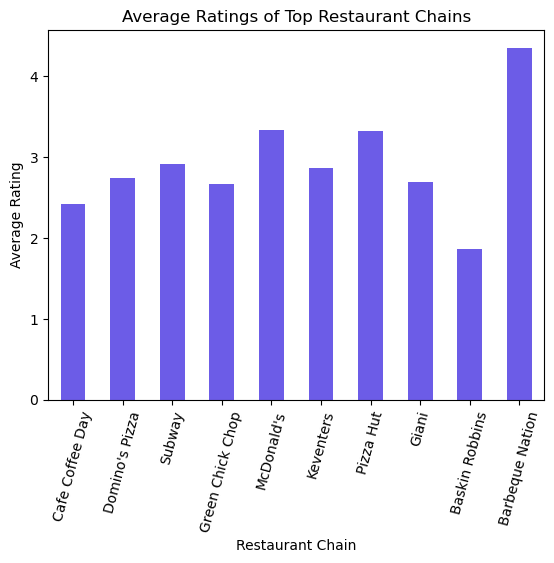

In [7]:
top_chain_ratings.plot(
    kind='bar',
    color='#6C5CE7'
)

plt.title('Average Ratings of Top Restaurant Chains')
plt.xlabel('Restaurant Chain')
plt.ylabel('Average Rating')
plt.xticks(rotation=75)

plt.show()

In [8]:
most_popular_chain = chains.idxmax()
most_popular_count = chains.max()

print("Most Popular Restaurant Chain:")
print(most_popular_chain)

print("\nNumber of Outlets:")
print(most_popular_count)

Most Popular Restaurant Chain:
Cafe Coffee Day

Number of Outlets:
83
